In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import yfinance as yf

import MLExtreme as mlx
from MLExtreme.unsupervised.feature_clustering.damex import damex

In [2]:
# 1. Get Data
tickers = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD', 'USDT-USD']
data = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']

C:\Users\adoni\AppData\Local\Temp\ipykernel_13408\2384493139.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']
[*********************100%***********************]  6 of 6 completed


In [3]:
# 2. Preprocessing (Get Negative Returns for "Crash" detection)
# We use negative returns because EVT focuses on the upper tail (maxima)
# A large positive value here = a large market crash
returns = -np.log(data / data.shift(1)).dropna()

if isinstance(returns.columns, pd.MultiIndex):
    returns.columns = returns.columns.get_level_values(0)

In [4]:
model = damex(epsilon=0.05, min_counts=0, 
            thresh_train=None, thresh_test=None, 
            include_singletons=True, rate=10)

X = returns.values
model.fit(X)

print(f"Model fitted. Total mass of extremes: {model.total_mass:.4f}")
print(f"Number of extreme events used (k): {model.number_extremes}")

Model fitted. Total mass of extremes: 3.2751
Number of extreme events used (k): 36


In [5]:
def interpret_damex_results(model, feature_names):
    """
    Maps the DAMEX output (indices) back to readable names (Tickers).
    """
    results = []
    
    for indices, mass in zip(model.subfaces, model.masses):
        # Convert indices [0, 2] -> "BTC-USD + BNB-USD"
        if len(indices) == 0:
            name = "Empty Cone"
        else:
            names = [feature_names[i] for i in indices]
            name = " + ".join(names)
            
        results.append({'Cone': name, 'Mass': mass, 'Dim': len(indices)})
    
    # Convert to DataFrame and sort by Mass
    df_res = pd.DataFrame(results).sort_values(by='Mass', ascending=False)
    return df_res

In [6]:
# Interpret the results
df_results = interpret_damex_results(model, returns.columns)

# Display the Top Cones
print("\n--- The Structure of Crypto Crashes ---")
print(df_results.head(10))


--- The Structure of Crypto Crashes ---
                                                Cone      Mass  Dim
0    BNB-USD + BTC-USD + ETH-USD + SOL-USD + XRP-USD  1.000735    5
1                                           USDT-USD  0.727807    1
2  BNB-USD + BTC-USD + ETH-USD + SOL-USD + USDT-U...  0.636832    6
3              BNB-USD + BTC-USD + ETH-USD + XRP-USD  0.363904    4
4                                 SOL-USD + USDT-USD  0.181952    2
5              BTC-USD + ETH-USD + SOL-USD + XRP-USD  0.090976    4
6              BNB-USD + ETH-USD + SOL-USD + XRP-USD  0.090976    4
7   BNB-USD + BTC-USD + ETH-USD + USDT-USD + XRP-USD  0.090976    5
8                        BNB-USD + SOL-USD + XRP-USD  0.090976    3
9                                            XRP-USD  0.090976    1


C:\Users\adoni\AppData\Local\Temp\ipykernel_13408\3467705388.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results.head(10), x='Mass', y='Cone', palette='viridis')


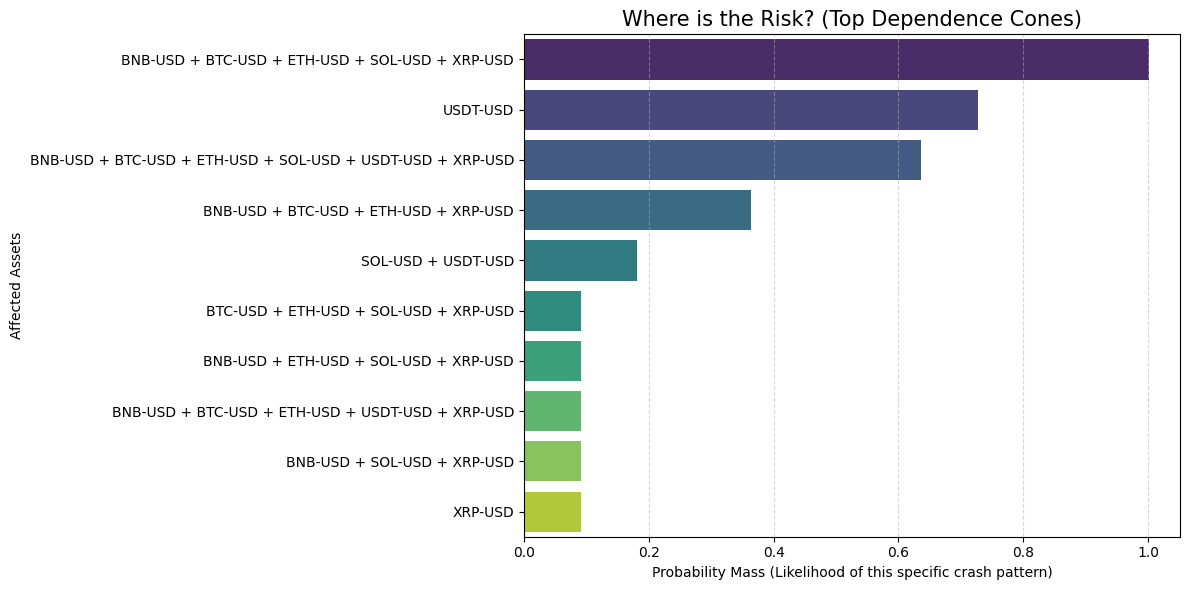

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results.head(10), x='Mass', y='Cone', palette='viridis')

plt.title('Where is the Risk? (Top Dependence Cones)', fontsize=15)
plt.xlabel('Probability Mass (Likelihood of this specific crash pattern)')
plt.ylabel('Affected Assets')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()